In [77]:
import pandas as pd 
import numpy as np


In [78]:
df = pd.read_csv("/home/fwzblk/Projects/prime2/pytorch-prime/p3/my_code/powerplant_data.csv")

In [79]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [80]:
#AT represents the temprature
# V represents the vaccum value 
# AP represents the pressure 
# RH represents the humididty 
# PE represnets the produced energy output and is the label for our data 

In [81]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [82]:
x = df.drop(labels="PE",axis=1)
x

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20
...,...,...,...,...
9563,15.12,48.92,1011.80,72.93
9564,33.41,77.95,1010.30,59.72
9565,15.99,43.34,1014.20,78.66
9566,17.65,59.87,1018.58,94.65


In [83]:
y = df['PE']
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

In [84]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train ,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)


In [86]:
import torch 
import torch.nn as nn
x_train_tensor = torch.tensor(x_train_scaled,dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_scaled,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype=float).view(-1,1)
y_test_tensor = torch.tensor(y_test.values , dtype=float).view(-1,1)

In [87]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_tensor,y_train_tensor)

test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [88]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader= DataLoader(test_dataset,batch_size=32)

In [89]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # first hidden layer
            nn.Linear(x_train.shape[1], 6),
            nn.ReLU(),

            # second hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [90]:
import torch.optim as optim 

model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


In [91]:
# train the ann
epochs = 100 
train_losses = []
val_losses=[]
best_val_loss=float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 

    for xb,yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output,yb)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            v_loss = criterion(outputs,yb)
            running_val_loss += v_loss

    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f'epoch {epoch+1}/{epochs}==> train loss = {epoch_train_loss} and val loss = {epoch_val_loss}')

    if epoch_val_loss < best_val_loss:
        best_val_loss= epoch_val_loss
        torch.save(model.state_dict(),"best-model.pt")

epoch 1/100==> train loss = 205896.37703899347 and val loss = 203469.83343435277
epoch 2/100==> train loss = 194082.65586854125 and val loss = 178886.8401235559
epoch 3/100==> train loss = 153613.0196498581 and val loss = 124417.57514915742
epoch 4/100==> train loss = 94906.37207618052 and val loss = 68450.0577079139
epoch 5/100==> train loss = 50578.4525235143 and val loss = 37298.88631994783
epoch 6/100==> train loss = 29590.663719675988 and val loss = 23840.190867910907
epoch 7/100==> train loss = 20335.31002713014 and val loss = 17450.82383152402
epoch 8/100==> train loss = 15532.39230875902 and val loss = 13446.341374762831
epoch 9/100==> train loss = 11930.997862786327 and val loss = 10037.295516121962
epoch 10/100==> train loss = 8716.2569696974 and val loss = 7024.239750065028
epoch 11/100==> train loss = 5908.284169449577 and val loss = 4583.388288359891
epoch 12/100==> train loss = 3761.5978332815625 and val loss = 2902.738383638358
epoch 13/100==> train loss = 2359.318045107

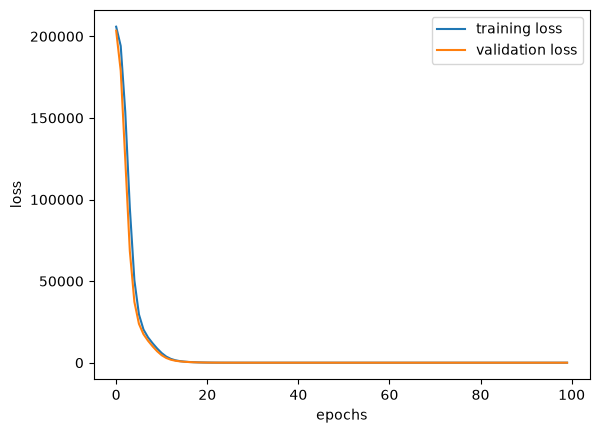

In [92]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss":train_losses,
    "Validation loss":val_losses,
})

plt.plot(loss_df["Training loss"],label='training loss')
plt.plot(loss_df["Validation loss"],label='validation loss')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

In [93]:
# loading the best model
model.load_state_dict(torch.load("best-model.pt"))


<All keys matched successfully>

In [94]:
model.eval()

with torch.no_grad():
    train_pred= model(x_train_tensor)
    test_pred = model(x_test_tensor)

    train_mse_loss = criterion(train_pred,y_train_tensor)
    test_mse_loss = criterion(test_pred,y_test_tensor)

print("training mse :",train_mse_loss)
print("testiing mse :",test_mse_loss)

training mse : tensor(21.2107, dtype=torch.float64)
testiing mse : tensor(19.5459, dtype=torch.float64)


In [95]:
from sklearn.metrics import r2_score as r2

print(f"r^2 score = {r2(y_test,test_pred)}")


r^2 score = 0.931692219106941


In [98]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=['predicted values'])
actual_df = pd.DataFrame(y_test.values,columns=['actual values'])
pd.concat([actual_df,predicted_df],axis=1)

,actual values,predicted values
0,433.27,435.583740
1,438.16,437.254822
2,458.42,461.199677
3,480.82,475.895081
4,441.41,435.921204
...,...,...
1909,456.70,451.178467
1910,438.04,432.000732
1911,467.80,467.441437
1912,437.14,431.520264
